In [42]:
import geopandas as gpd
import pandas as pd
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ee
import xarray as xr
import xee
from shapely.geometry import mapping
import json
ee.Authenticate()
ee.Initialize( opt_url='https://earthengine-highvolume.googleapis.com')
import warnings
from skimage import measure
warnings.filterwarnings("ignore")

In [2]:
from pysheds.grid import Grid

https://github.com/pysheds/pysheds

In [3]:
# Define Bounding Box 
bbox1=[76.48815950000001, 9.165505398999999, 76.5081595, 9.185505399]

In [4]:
# converting to gee readable geometry
bbox = ee.Geometry.Rectangle(bbox1)

In [17]:
# =========================================================
# SRTM DEM (30m, single static image — no time dimension)
# =========================================================
srtm   = ee.Image('USGS/SRTMGL1_003').select('elevation').clip(bbox)
slope  = ee.Terrain.slope(srtm).rename('slope')          # degrees
aspect = ee.Terrain.aspect(srtm).rename('aspect')         # degrees, 0-360
hillshade = ee.Terrain.hillshade(srtm).rename('hillshade')  # 0-255, default sun az=270, elev=45
terrain_img = srtm.rename('elevation').addBands([slope, aspect, hillshade])
ds_srtm = xr.open_dataset(
    ee.ImageCollection([terrain_img]),
    engine='ee',
    crs='EPSG:4326',
    scale=0.0002777777777777778,
    geometry=bbox
)

ds_srtm = ds_srtm.sortby('lat', ascending=False)
ds_srtm = ds_srtm.transpose('time', 'lat', 'lon')
dem       = terrain['elevation']
# Drop time dim (static dataset)
terrain = ds_srtm.isel(time=0).drop_vars('time')



In [12]:
ds_srtm

<xarray.Dataset> Size: 84kB
Dimensions:    (time: 1, lon: 72, lat: 72)
Coordinates:
  * time       (time) int64 8B 0
  * lon        (lon) float64 576B 76.49 76.49 76.49 76.49 ... 76.51 76.51 76.51
  * lat        (lat) float64 576B 9.185 9.185 9.185 9.185 ... 9.166 9.166 9.166
Data variables:
    elevation  (time, lat, lon) float32 21kB ...
    slope      (time, lat, lon) float32 21kB ...
    aspect     (time, lat, lon) float32 21kB ...
    hillshade  (time, lat, lon) float32 21kB ...
Attributes:
    crs:      EPSG:4326

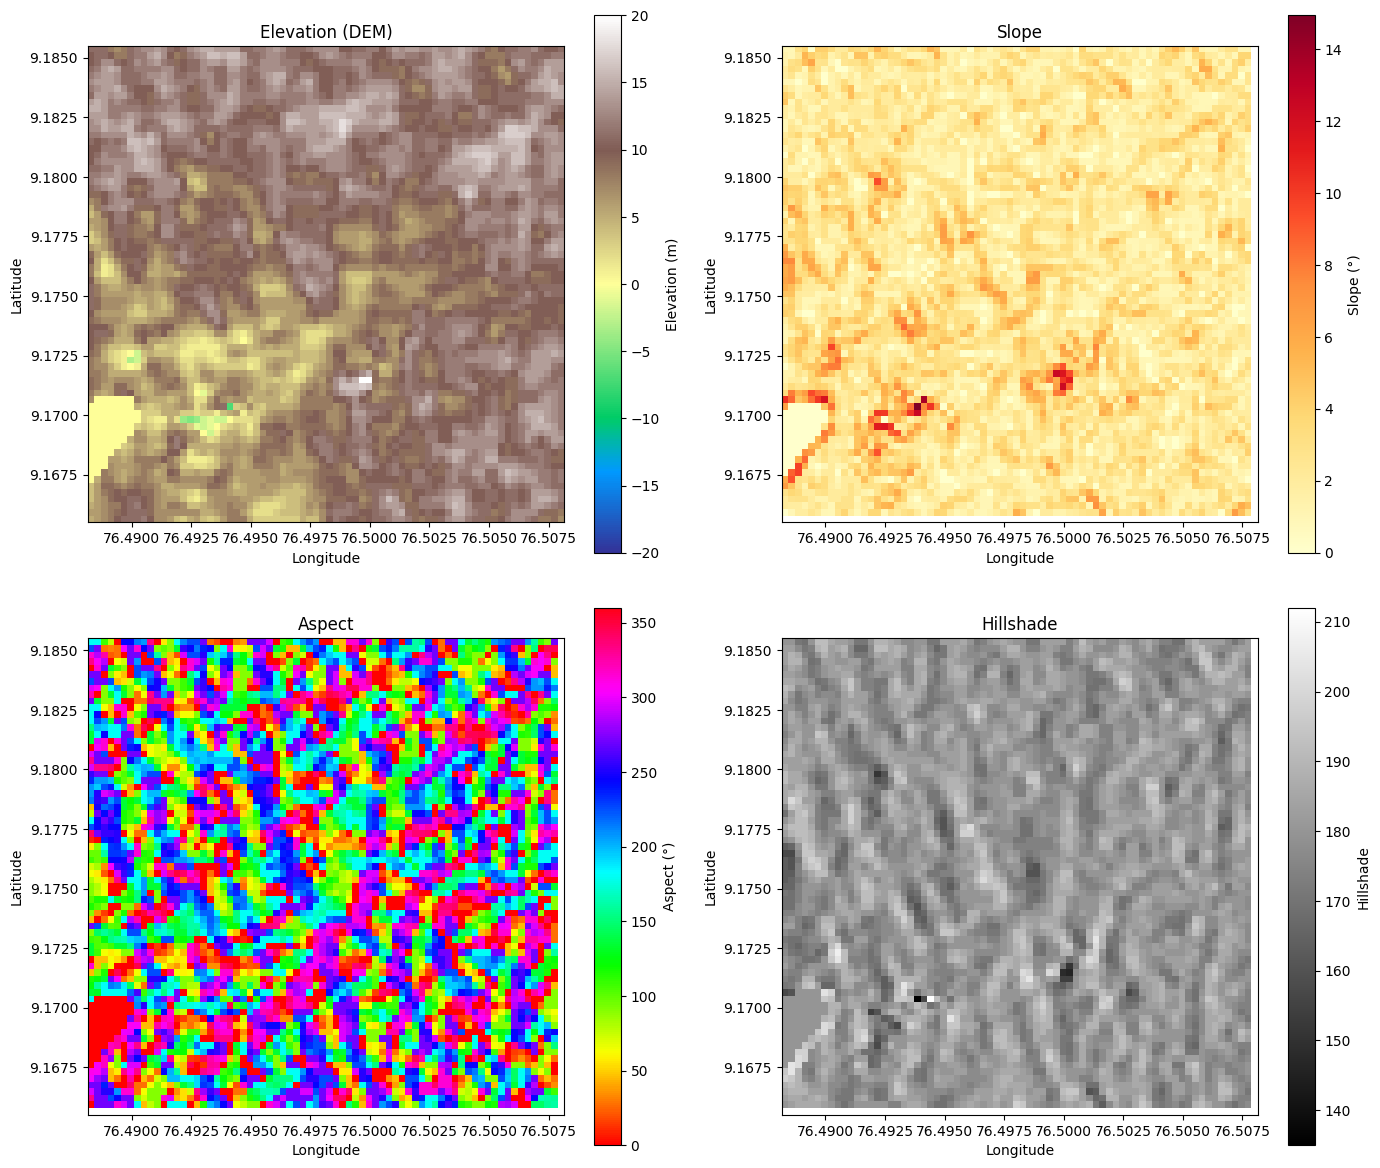

In [14]:


fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Elevation ---
dem.plot(ax=axes[0, 0], cmap='terrain', cbar_kwargs={'label': 'Elevation (m)'})
axes[0, 0].set_title('Elevation (DEM)')

# --- Slope ---
slope_da.plot(ax=axes[0, 1], cmap='YlOrRd', cbar_kwargs={'label': 'Slope (°)'})
axes[0, 1].set_title('Slope')

# --- Aspect (circular colormap since it's directional 0-360°) ---
aspect_da.plot(ax=axes[1, 0], cmap='hsv', vmin=0, vmax=360, cbar_kwargs={'label': 'Aspect (°)'})
axes[1, 0].set_title('Aspect')

# --- Hillshade ---
hillshade_da.plot(ax=axes[1, 1], cmap='gray', cbar_kwargs={'label': 'Hillshade'})
axes[1, 1].set_title('Hillshade')

for ax in axes.flat:
    ax.set_aspect('equal')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

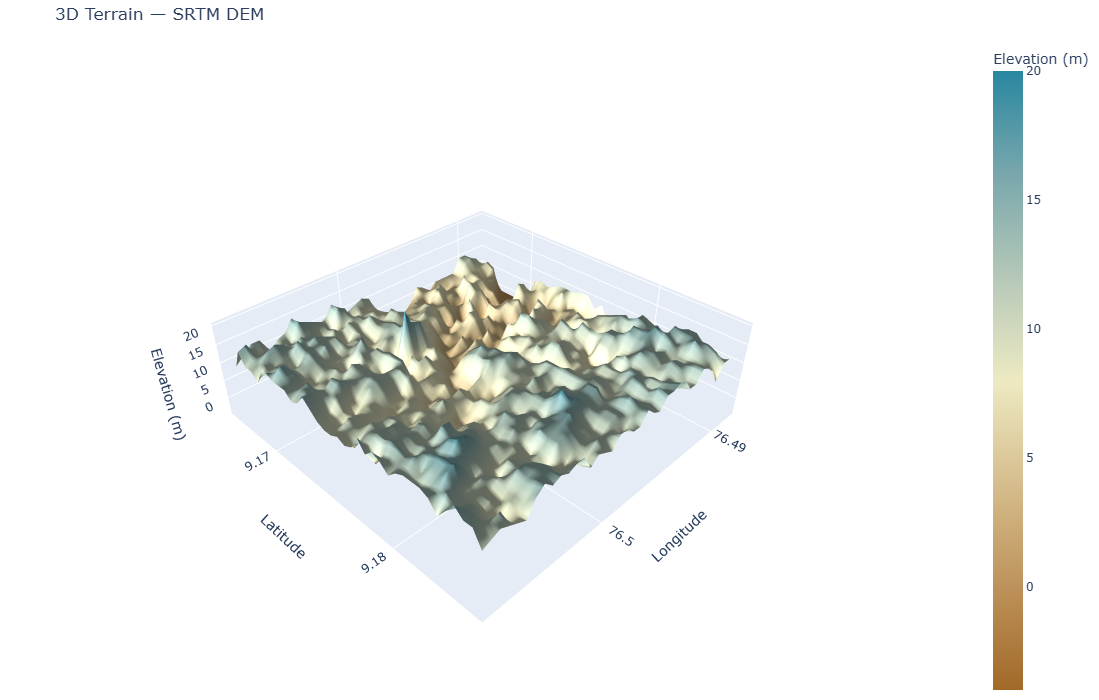

In [15]:
import plotly.graph_objects as go
import numpy as np

# Downsample if the DEM is large — full-res 30m grids can be very slow to render interactively
# Adjust the step to balance detail vs performance
step = 2  # try 1 for full res if your grid is small, higher (4, 5...) if it's huge
dem_ds = dem.isel(lat=slice(None, None, step), lon=slice(None, None, step))

fig = go.Figure(data=[go.Surface(
    z=dem_ds.values,
    x=dem_ds.lon.values,
    y=dem_ds.lat.values,
    colorscale='earth',
    colorbar=dict(title='Elevation (m)'),
    lighting=dict(ambient=0.5, diffuse=0.8, specular=0.3, roughness=0.6),
    lightposition=dict(x=100, y=200, z=1000)
)])

fig.update_layout(
    title='3D Terrain — SRTM DEM',
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Elevation (m)',
        # Exaggerate vertical scale for visibility — real terrain often looks flat otherwise
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.3),
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()

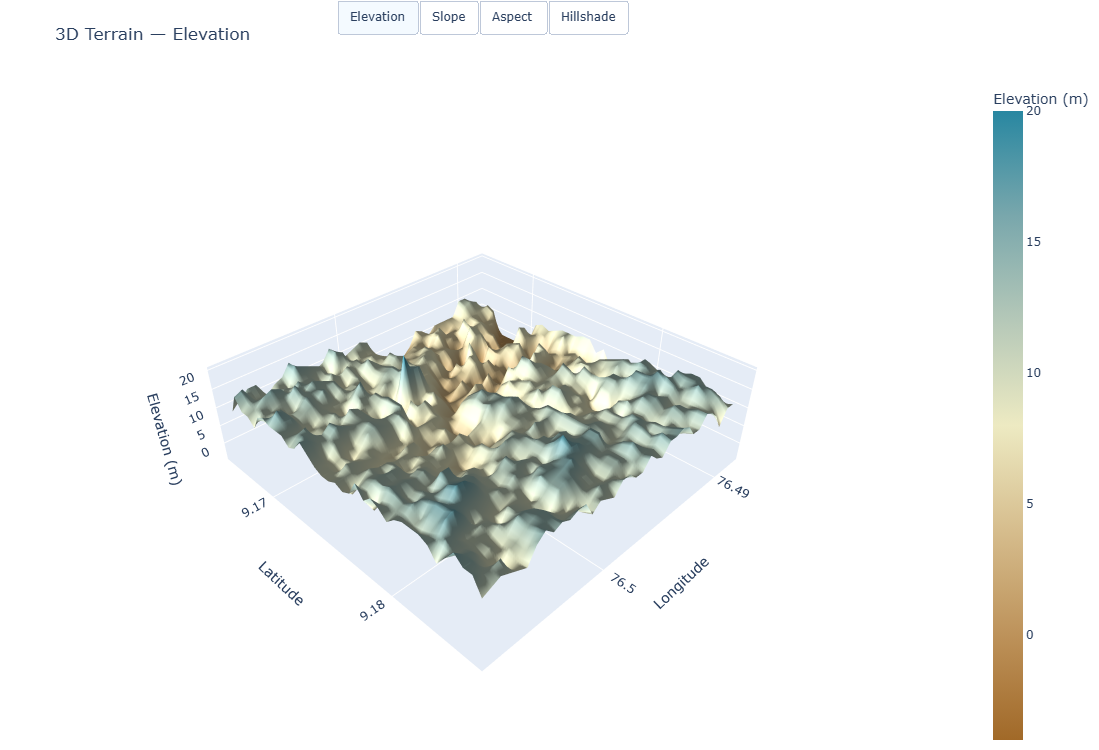

In [16]:
import plotly.graph_objects as go
import numpy as np

# Downsample for interactive performance
step = 2
dem_ds       = dem.isel(lat=slice(None, None, step), lon=slice(None, None, step))
slope_ds     = slope_da.isel(lat=slice(None, None, step), lon=slice(None, None, step))
aspect_ds    = aspect_da.isel(lat=slice(None, None, step), lon=slice(None, None, step))
hillshade_ds = hillshade_da.isel(lat=slice(None, None, step), lon=slice(None, None, step))

surface = go.Surface(
    z=dem_ds.values,
    x=dem_ds.lon.values,
    y=dem_ds.lat.values,
    surfacecolor=dem_ds.values,          # default layer shown = elevation
    colorscale='earth',
    colorbar=dict(title='Elevation (m)'),
    lighting=dict(ambient=0.5, diffuse=0.8, specular=0.3, roughness=0.6),
    lightposition=dict(x=100, y=200, z=1000)
)

fig = go.Figure(data=[surface])

fig.update_layout(
    title='3D Terrain — Elevation',
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Elevation (m)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.3),
    ),
    width=950,
    height=750,
    margin=dict(l=0, r=0, t=60, b=0),
    updatemenus=[dict(
        type='buttons',
        direction='left',
        x=0.5, xanchor='center',
        y=1.12, yanchor='top',
        showactive=True,
        buttons=[
            dict(
                label='Elevation',
                method='update',
                args=[
                    {'surfacecolor': [dem_ds.values], 'colorscale': [[[0,'#1a5d1a'],[0.5,'#e0d68a'],[1,'#8b5a2b']]] if False else 'earth'},
                    {'title': '3D Terrain — Elevation', 'scene.zaxis.title': 'Elevation (m)', 'coloraxis.colorbar.title': 'Elevation (m)'}
                ]
            ),
            dict(
                label='Slope',
                method='update',
                args=[
                    {'surfacecolor': [slope_ds.values], 'colorscale': 'YlOrRd'},
                    {'title': '3D Terrain — Slope', 'scene.zaxis.title': 'Elevation (m)'}
                ]
            ),
            dict(
                label='Aspect',
                method='update',
                args=[
                    {'surfacecolor': [aspect_ds.values], 'colorscale': 'hsv', 'cmin': 0, 'cmax': 360},
                    {'title': '3D Terrain — Aspect', 'scene.zaxis.title': 'Elevation (m)'}
                ]
            ),
            dict(
                label='Hillshade',
                method='update',
                args=[
                    {'surfacecolor': [hillshade_ds.values], 'colorscale': 'gray'},
                    {'title': '3D Terrain — Hillshade', 'scene.zaxis.title': 'Elevation (m)'}
                ]
            ),
        ]
    )]
)

fig.show()

In [18]:
dem = dem.rename({"lon": "x", "lat": "y"})

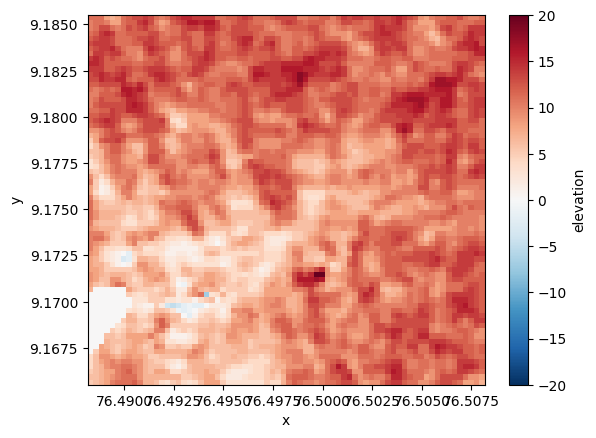

In [19]:
dem.plot()

In [20]:
from pysheds.grid import Grid
from pysheds.sview import Raster, ViewFinder
import numpy as np
from affine import Affine

# --- Get numpy array + geospatial metadata from xarray (no disk write) ---
dem_arr = dem.values.astype(np.float64)          # 2D numpy array
transform = dem.rio.transform()                   # affine transform from rioxarray
crs = dem.rio.crs.to_wkt()                        # or dem.rio.crs directly

# --- Build a pysheds Raster + ViewFinder manually ---
viewfinder = ViewFinder(
    affine=transform,
    shape=dem_arr.shape,
    crs=crs,
    nodata=np.nan
)
dem_r = Raster(dem_arr, viewfinder=viewfinder)

# --- Build the Grid from that raster ---
grid = Grid.from_raster(dem_r)

In [10]:
grid

'affine' : Affine(0.0002777777777778587, 0.0, 76.48815950000001,
       0.0, -0.0002777777777777837, 9.185505399)
'shape' : (72, 72)
'nodata' : nan
'crs' : <Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

'mask' : array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [21]:
pit_filled = grid.fill_pits(dem_r)
flooded    = grid.fill_depressions(pit_filled)
inflated   = grid.resolve_flats(flooded)

fdir = grid.flowdir(inflated)
acc  = grid.accumulation(fdir)

In [23]:
import ipyleaflet
import ipywidgets
import numpy as np
import base64
from io import BytesIO
from PIL import Image
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from rasterio.transform import array_bounds
from ipyleaflet import (
    Map,
    ImageOverlay,
    DrawControl,
    Marker,
    LayersControl,
    WidgetControl,
)
from ipywidgets import HTML, VBox

# ==========================================================
# Convert array to PNG
# ==========================================================
def array_to_data_url(arr, cmap_name="terrain", log=False):
    arr = np.asarray(arr, dtype=float)
    arr = np.nan_to_num(arr)
    if log:
        arr = np.log1p(np.clip(arr, 0, None))
    norm = mcolors.Normalize(arr.min(), arr.max())
    rgba = (cm.get_cmap(cmap_name)(norm(arr)) * 255).astype(np.uint8)
    img = Image.fromarray(rgba)
    buf = BytesIO()
    img.save(buf, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

# ==========================================================
# Raster Layers
# ==========================================================
layer_urls = {
    "DEM": array_to_data_url(dem_r),
    "Pit Filled": array_to_data_url(pit_filled),
    "Depressions Filled": array_to_data_url(flooded),
    "Flats Resolved": array_to_data_url(inflated),
    "Flow Direction": array_to_data_url(fdir, "twilight"),
    "Flow Accumulation": array_to_data_url(acc, "cubehelix", log=True),
}

transform = grid.affine
rows, cols = dem_r.shape
west, south, east, north = array_bounds(rows, cols, transform)
bounds = [[south, west], [north, east]]
center = [(south + north) / 2, (west + east) / 2]

# ==========================================================
# Map
# ==========================================================
m = Map(center=center, zoom=15)

for name, url in layer_urls.items():
    m.add(
        ImageOverlay(
            url=url,
            bounds=bounds,
            name=name,
            opacity=1
        )
    )

m.add(LayersControl(position="topright"))
m.fit_bounds(bounds)

# ==========================================================
# Variables
# ==========================================================
selected_point = {}
selected_lat = None
selected_lon = None
current_marker = None

status = HTML("<b>Select the marker tool and click once.</b>")
m.add(
    WidgetControl(
        widget=VBox([status]),
        position="bottomleft"
    )
)

# ==========================================================
# Draw control — ONLY marker enabled
# ==========================================================
draw = DrawControl(
    marker={"shapeOptions": {"color": "#3388ff"}},  # enabled
    polygon={},        # disabled
    rectangle={},       # disabled
    polyline={},         # disabled
    circle={},           # disabled
    circlemarker={},     # disabled
)

# ==========================================================
# Callback
# ==========================================================
def handle_draw(target, action, geo_json):
    global current_marker, selected_lat, selected_lon

    print(action)
    print(geo_json)

    if action != "created":
        return

    lon, lat = geo_json["geometry"]["coordinates"]
    selected_lat = lat
    selected_lon = lon

    selected_point.clear()
    selected_point["lat"] = lat
    selected_point["lon"] = lon
    selected_point["x"] = lon
    selected_point["y"] = lat

    # Remove previous marker if it exists
    if current_marker is not None:
        try:
            m.remove(current_marker)
        except Exception:
            pass

    # Add a persistent marker at the clicked location
    current_marker = Marker(location=(lat, lon), draggable=False)
    m.add(current_marker)

    status.value = (
        f"<b>Selected</b><br>"
        f"Latitude : {lat:.6f}<br>"
        f"Longitude: {lon:.6f}"
    )

    print(selected_point)

draw.on_draw(handle_draw)
m.add(draw)
m

Map(center=[9.175505399, 76.49815950000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_…

In [24]:
stream_threshold=10
x, y = selected_point['lon'], selected_point['lat']
streams = acc > stream_threshold
x_snap, y_snap = grid.snap_to_mask(acc > stream_threshold, (x, y))
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, xytype='coordinate')

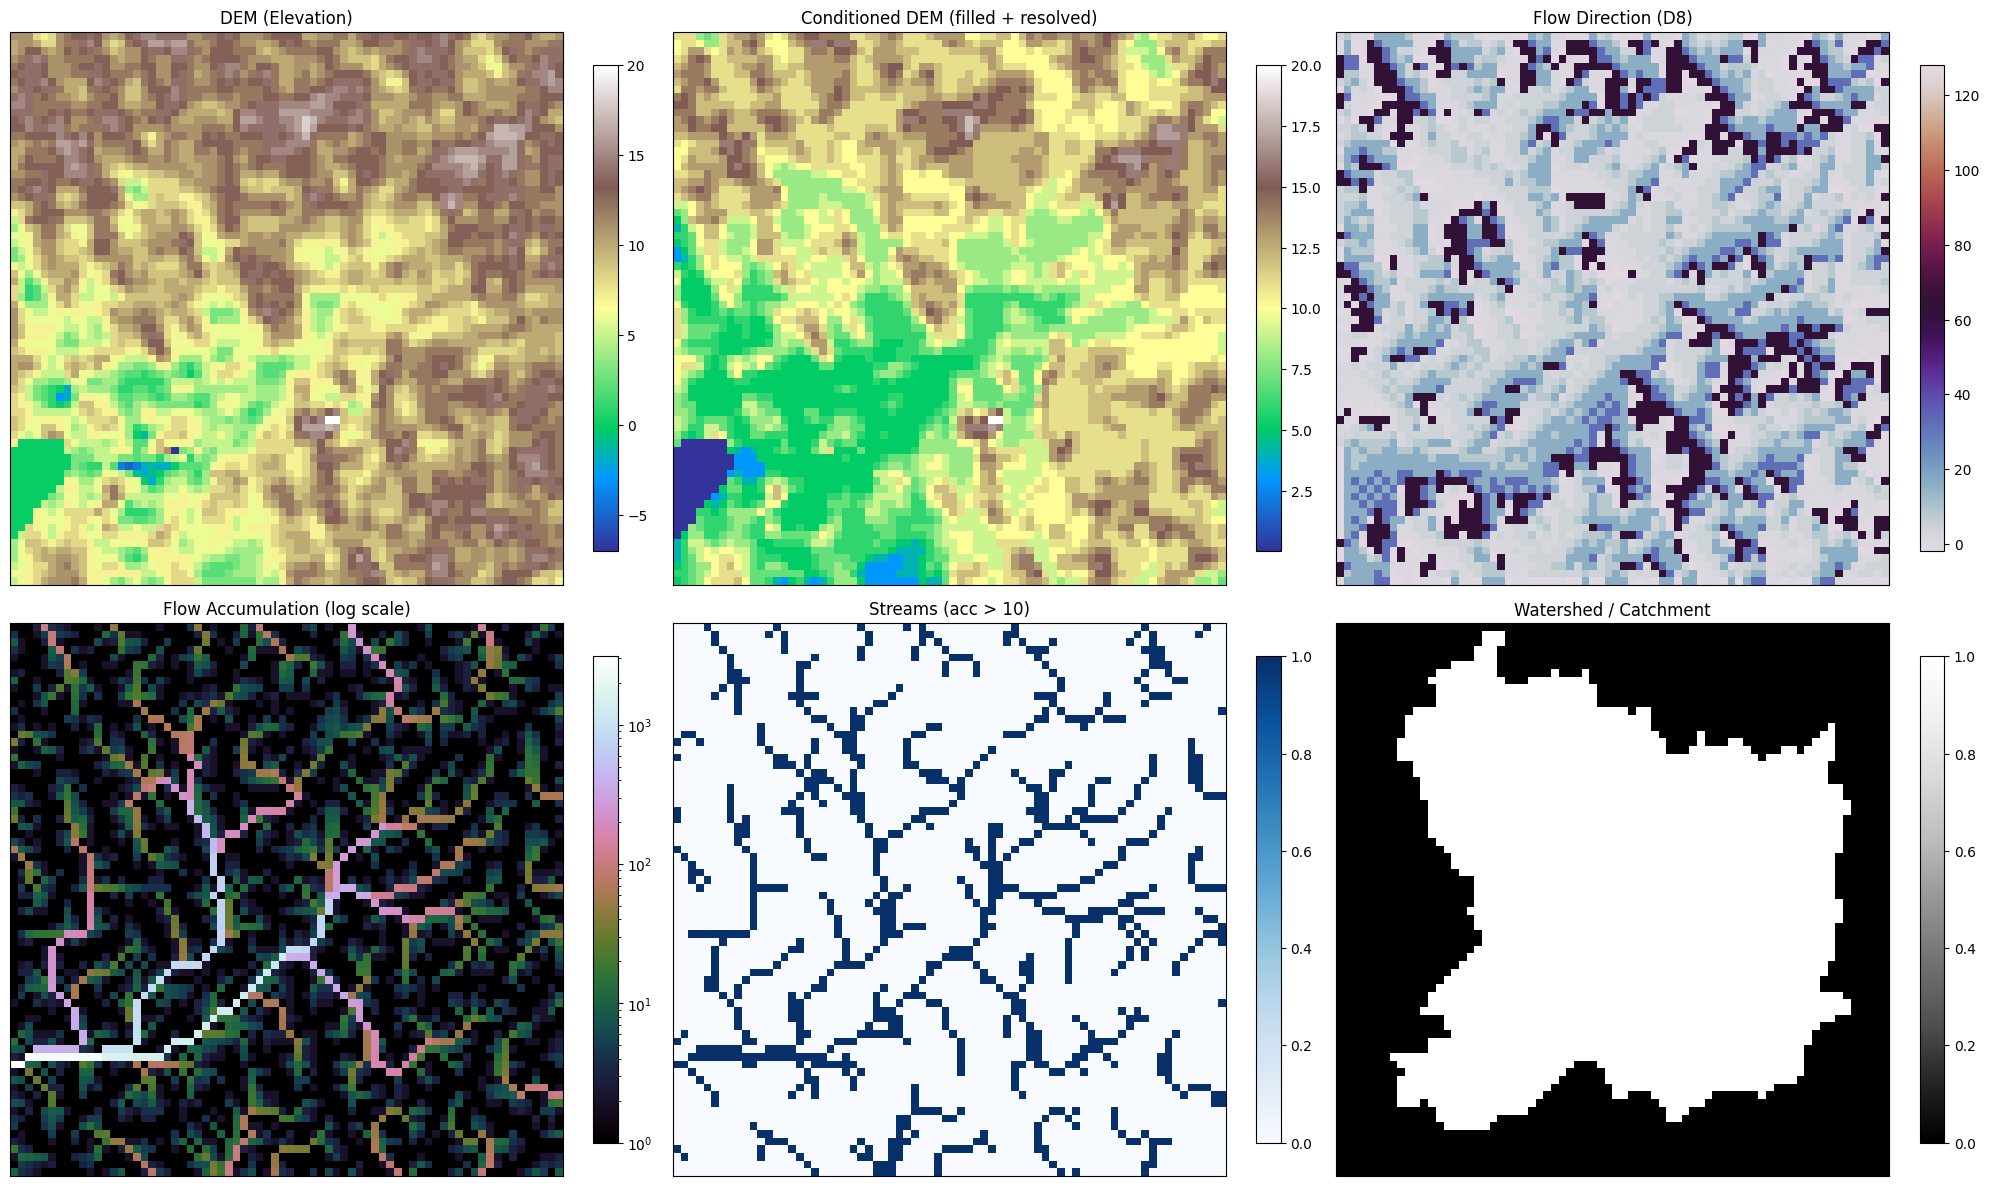

In [25]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# --- 1. Original DEM ---
im0 = axes[0,0].imshow(dem_arr, cmap='terrain')
axes[0,0].set_title('DEM (Elevation)')
fig.colorbar(im0, ax=axes[0,0], fraction=0.04)

# --- 2. Filled/conditioned DEM ---
im1 = axes[0,1].imshow(inflated, cmap='terrain')
axes[0,1].set_title('Conditioned DEM (filled + resolved)')
fig.colorbar(im1, ax=axes[0,1], fraction=0.04)

# --- 3. Flow direction ---
im2 = axes[0,2].imshow(fdir, cmap='twilight')
axes[0,2].set_title('Flow Direction (D8)')
fig.colorbar(im2, ax=axes[0,2], fraction=0.04)

# --- 4. Flow accumulation (log scale, since it's highly skewed) ---
im3 = axes[1,0].imshow(acc, cmap='cubehelix',
                        norm=colors.LogNorm(vmin=1, vmax=acc.max()))
axes[1,0].set_title('Flow Accumulation (log scale)')
fig.colorbar(im3, ax=axes[1,0], fraction=0.04)

# --- 5. Extracted stream network ---
im4 = axes[1,1].imshow(streams, cmap='Blues')
axes[1,1].set_title(f'Streams (acc > {stream_threshold})')
fig.colorbar(im4, ax=axes[1,1], fraction=0.04)

# --- 6. Delineated watershed / catchment ---
im5 = axes[1,2].imshow(catch, cmap='Greys_r')
axes[1,2].set_title('Watershed / Catchment')
fig.colorbar(im5, ax=axes[1,2], fraction=0.04)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [26]:
import numpy as np
import base64
from io import BytesIO
from PIL import Image
from rasterio.transform import array_bounds
from ipyleaflet import Map, ImageOverlay, WidgetControl
from ipywidgets import IntSlider, VBox, HTML, interactive_output

# ==========================================================
# Convert a boolean stream mask to a transparent PNG overlay
# ==========================================================
def stream_mask_to_data_url(mask, color=(0, 120, 255, 255)):
    """
    mask: 2D boolean array (True = stream pixel)
    color: RGBA for stream pixels; background is fully transparent
    """
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)
    rgba[mask] = color
    img = Image.fromarray(rgba, mode="RGBA")
    buf = BytesIO()
    img.save(buf, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

# ==========================================================
# Bounds (reuse your existing grid/transform)
# ==========================================================
transform = grid.affine
rows, cols = acc.shape
west, south, east, north = array_bounds(rows, cols, transform)
bounds = [[south, west], [north, east]]
center = [(south + north) / 2, (west + east) / 2]

# ==========================================================
# Map
# ==========================================================
m = Map(center=center, zoom=15)

# Optional: show accumulation as a faint basemap-ish backdrop
# (comment out if you only want the stream overlay)
# m.add(ImageOverlay(url=array_to_data_url(acc, "cubehelix", log=True), bounds=bounds, name="Flow Accumulation", opacity=0.5))

acc_max = int(np.nanmax(acc))

initial_threshold = 10
stream_overlay = ImageOverlay(
    url=stream_mask_to_data_url(acc > initial_threshold),
    bounds=bounds,
    name="Streams",
    opacity=1,
)
m.add(stream_overlay)
m.fit_bounds(bounds)

# ==========================================================
# Slider + info panel
# ==========================================================
slider = IntSlider(
    value=initial_threshold,
    min=1,
    max=min(acc_max, 100000),   # cap the range so it's usable; adjust as needed
    step=1,
    description="Threshold:",
    continuous_update=False,     # set True for live drag updates (can be slow)
    style={"description_width": "initial"},
    layout={"width": "400px"},
)

info = HTML()

def update_streams(threshold):
    mask = acc > threshold
    n_pixels = int(mask.sum())
    stream_overlay.url = stream_mask_to_data_url(mask)
    info.value = f"<b>Threshold:</b> {threshold} &nbsp; <b>Stream pixels:</b> {n_pixels:,}"

out = interactive_output(update_streams, {"threshold": slider})

control_panel = VBox([slider, info])
m.add(WidgetControl(widget=control_panel, position="bottomleft"))

# Trigger initial info text
update_streams(initial_threshold)

display(m, out)

Map(center=[9.175505399, 76.49815950000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_…

Output()

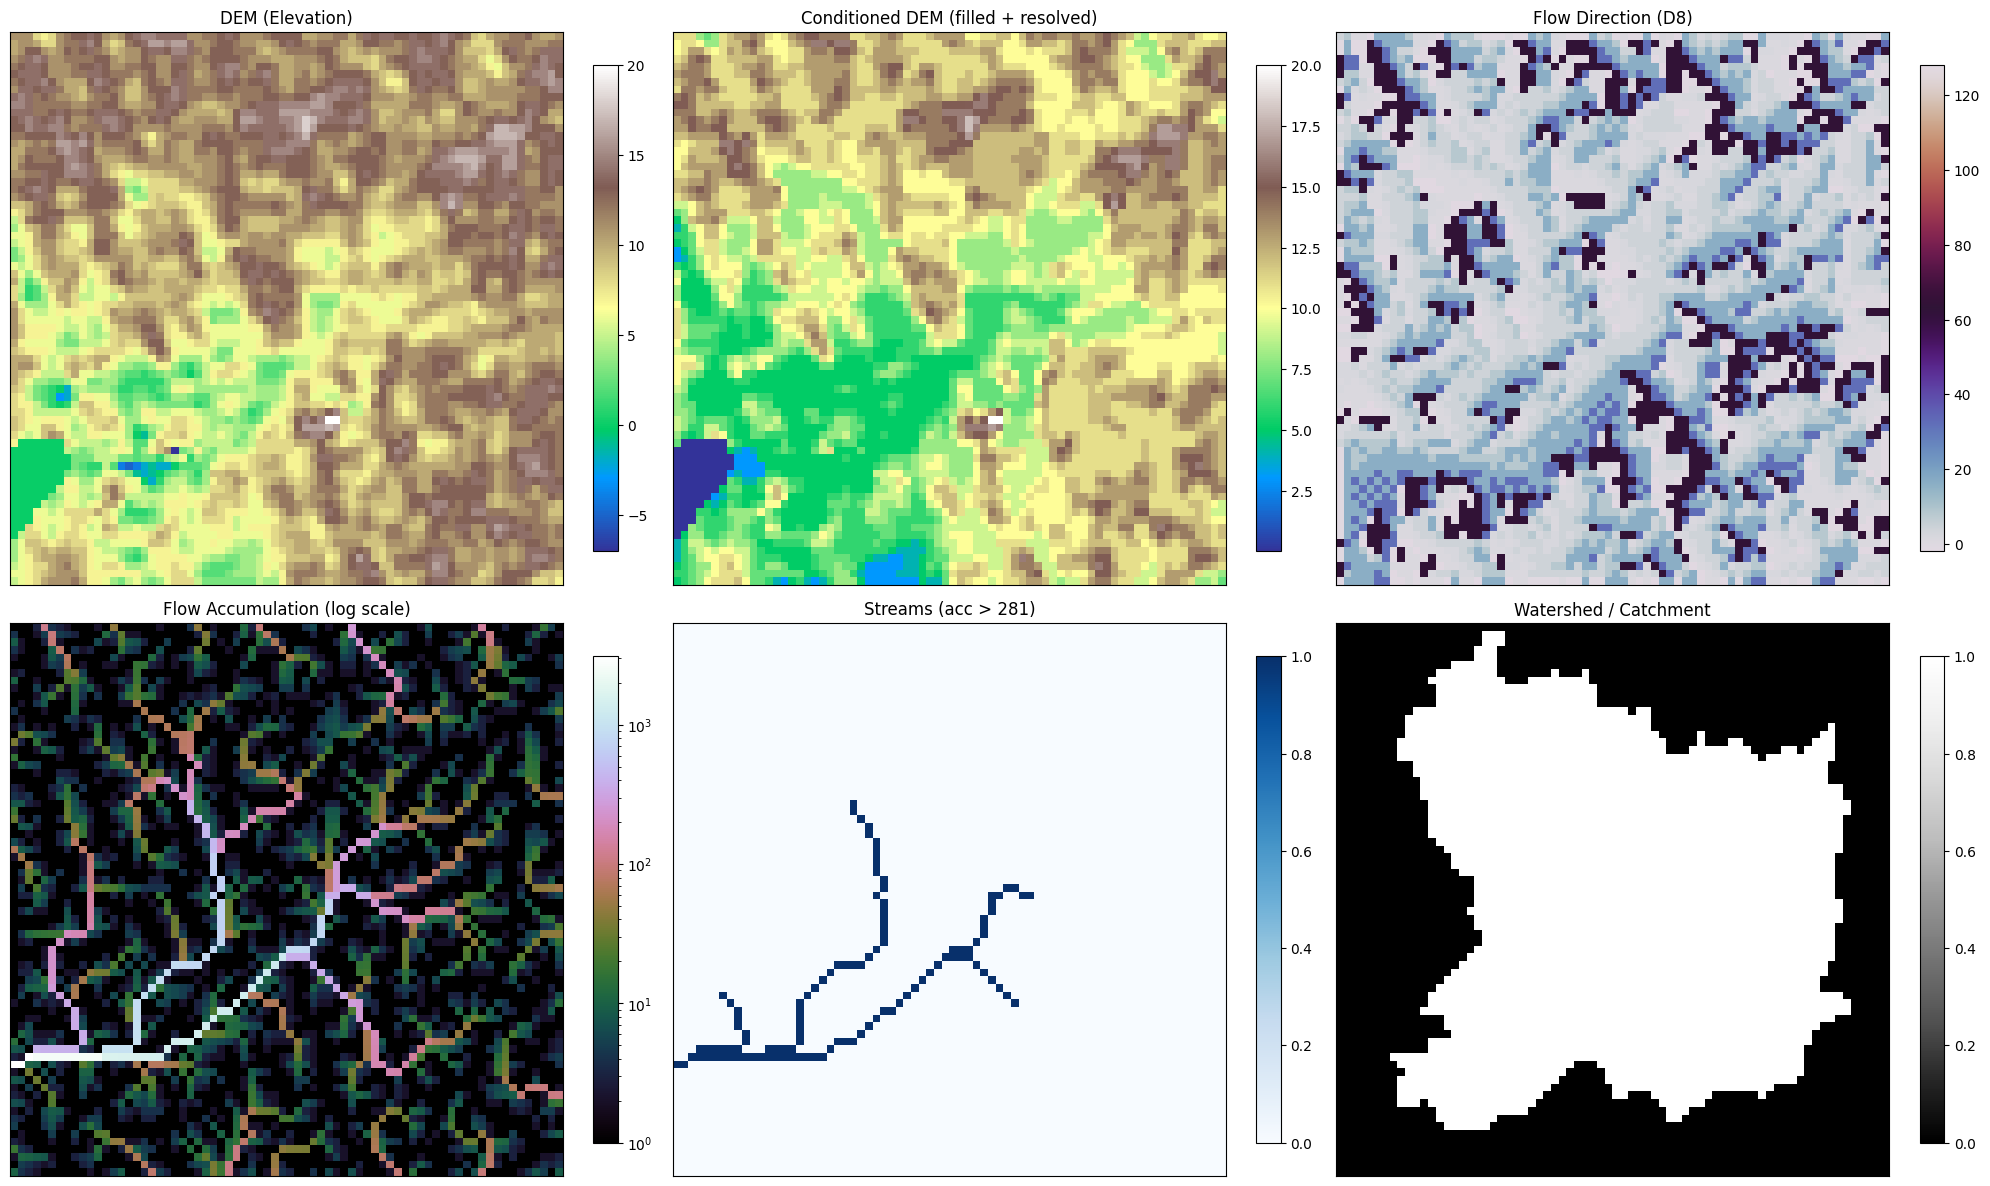

In [27]:
stream_threshold=281
x, y = selected_point['lon'], selected_point['lat']
streams = acc > stream_threshold
x_snap, y_snap = grid.snap_to_mask(acc > stream_threshold, (x, y))
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, xytype='coordinate')
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# --- 1. Original DEM ---
im0 = axes[0,0].imshow(dem_arr, cmap='terrain')
axes[0,0].set_title('DEM (Elevation)')
fig.colorbar(im0, ax=axes[0,0], fraction=0.04)

# --- 2. Filled/conditioned DEM ---
im1 = axes[0,1].imshow(inflated, cmap='terrain')
axes[0,1].set_title('Conditioned DEM (filled + resolved)')
fig.colorbar(im1, ax=axes[0,1], fraction=0.04)

# --- 3. Flow direction ---
im2 = axes[0,2].imshow(fdir, cmap='twilight')
axes[0,2].set_title('Flow Direction (D8)')
fig.colorbar(im2, ax=axes[0,2], fraction=0.04)

# --- 4. Flow accumulation (log scale, since it's highly skewed) ---
im3 = axes[1,0].imshow(acc, cmap='cubehelix',
                        norm=colors.LogNorm(vmin=1, vmax=acc.max()))
axes[1,0].set_title('Flow Accumulation (log scale)')
fig.colorbar(im3, ax=axes[1,0], fraction=0.04)

# --- 5. Extracted stream network ---
im4 = axes[1,1].imshow(streams, cmap='Blues')
axes[1,1].set_title(f'Streams (acc > {stream_threshold})')
fig.colorbar(im4, ax=axes[1,1], fraction=0.04)

# --- 6. Delineated watershed / catchment ---
im5 = axes[1,2].imshow(catch, cmap='Greys_r')
axes[1,2].set_title('Watershed / Catchment')
fig.colorbar(im5, ax=axes[1,2], fraction=0.04)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [28]:
from rasterio.features import shapes
from shapely.geometry import shape

# ==========================================================
# Prepare catchment mask: 1 = inside catchment, NaN = outside
# ==========================================================
catch_mask = np.where(catch, 1, np.nan).astype("float32")

# rasterio.features.shapes needs a mask to know which pixels to
# turn into polygons — we only want pixels where catch == 1
valid_mask = ~np.isnan(catch_mask)

# ==========================================================
# Polygonize
# ==========================================================
transform = grid.affine  # same affine used for your DEM/streams

polygons = []
values = []

for geom, val in shapes(catch_mask, mask=valid_mask, transform=transform):
    polygons.append(shape(geom))
    values.append(val)

# ==========================================================
# Build GeoDataFrame and save
# ==========================================================
gdf = gpd.GeoDataFrame({"value": values}, geometry=polygons, crs=grid.crs)

# Optional: dissolve into a single catchment polygon (removes internal
# pixel-boundary seams so you get one clean shape instead of many small ones)
gdf_dissolved = gdf.dissolve(by="value").reset_index()

output_path = "catchment.shp"
gdf_dissolved.to_file(output_path)

print(f"Saved catchment shapefile to {output_path}")
print(gdf_dissolved)

Saved catchment shapefile to catchment.shp
   value                                           geometry
0    1.0  POLYGON ((76.49344 9.18523, 76.49344 9.18467, ...


<Axes: >

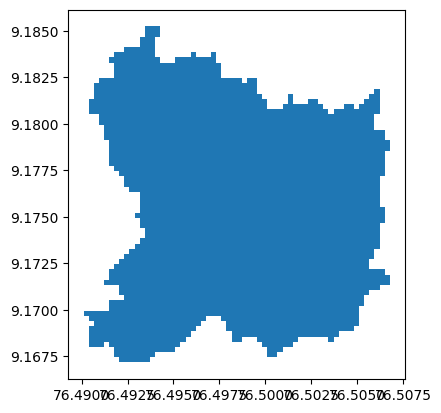

In [29]:
gdf_dissolved.plot()

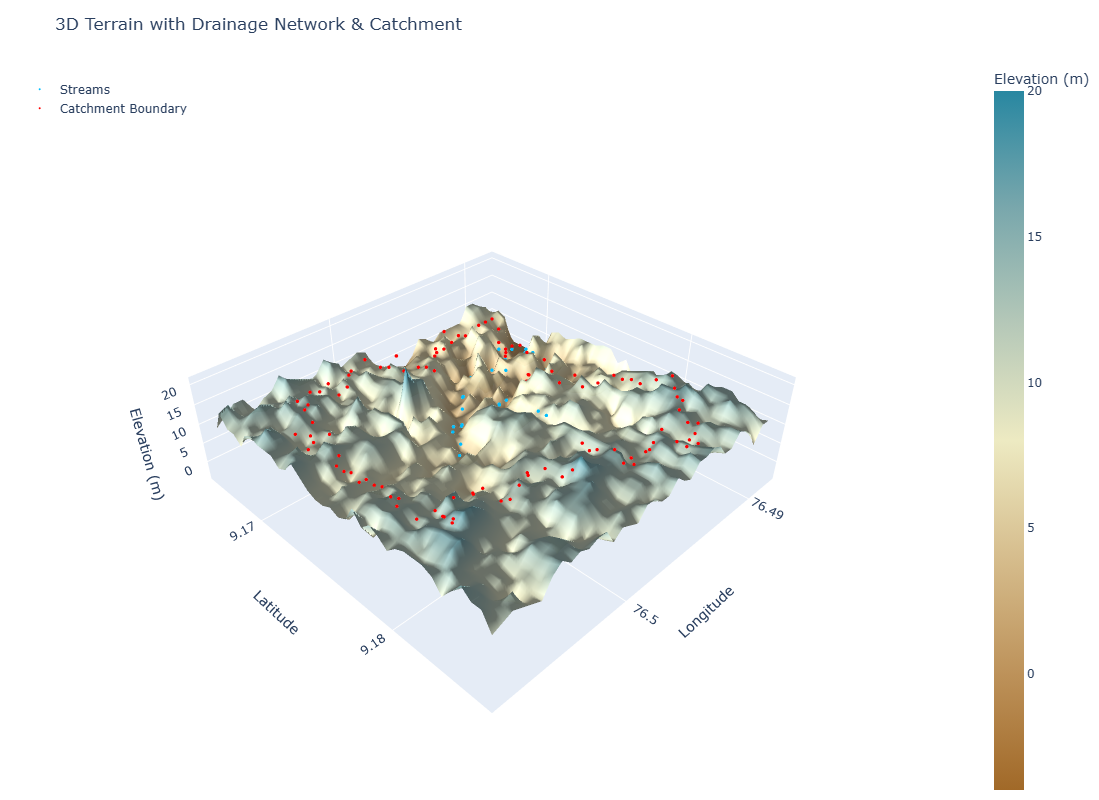

In [38]:

# --- Downsample for performance ---
step = 2
#dem = dem.rename({'y': 'lat', 'x': 'lon'})
dem_ds = dem.isel(lat=slice(None, None, step), lon=slice(None, None, step))

dims = dem_ds.dims
lat_dim = 'lat' if 'lat' in dims else 'y'
lon_dim = 'lon' if 'lon' in dims else 'x'

surface = go.Surface(
    z=dem_ds.values,
    x=dem_ds[lon_dim].values,
    y=dem_ds[lat_dim].values,
    surfacecolor=dem_ds.values,
    colorscale='earth',
    colorbar=dict(title='Elevation (m)', x=1.0),
    opacity=0.95,
    lighting=dict(ambient=0.5, diffuse=0.8, specular=0.3, roughness=0.6),
    lightposition=dict(x=100, y=200, z=1000),
    name='Elevation'
)
fig = go.Figure(data=[surface])

# --- Overlay: Stream network as 3D scatter, draped at DEM height + small offset ---
# streams_arr must be aligned to the SAME grid as dem_ds (resample if shapes differ, see note below)
rows, cols = np.where(streams[::step, ::step] > 0)
stream_lon = dem_ds.lon.values[cols]
stream_lat = dem_ds.lat.values[rows]
stream_z   = dem_ds.values[rows, cols] + 2   # small z-offset so streams sit visibly above terrain

fig.add_trace(go.Scatter3d(
    x=stream_lon, y=stream_lat, z=stream_z,
    mode='markers',
    marker=dict(size=2, color='deepskyblue'),
    name='Streams'
))

# --- Overlay: Catchment boundary as a 3D line ---
# Extract boundary pixels of the catchment mask, then drape them on the DEM
from scipy import ndimage
catch_resampled = catch[::step, ::step] if catch.shape == streams.shape else None

if catch_resampled is not None:
    boundary = catch_resampled.astype(bool) ^ ndimage.binary_erosion(catch_resampled.astype(bool))
    b_rows, b_cols = np.where(boundary)
    boundary_lon = dem_ds.lon.values[b_cols]
    boundary_lat = dem_ds.lat.values[b_rows]
    boundary_z   = dem_ds.values[b_rows, b_cols] + 3

    fig.add_trace(go.Scatter3d(
        x=boundary_lon, y=boundary_lat, z=boundary_z,
        mode='markers',
        marker=dict(size=2, color='red'),
        name='Catchment Boundary'
    ))

fig.update_layout(
    title='3D Terrain with Drainage Network & Catchment',
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Elevation (m)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.3),
    ),
    width=1000,
    height=800,
    margin=dict(l=0, r=0, t=60, b=0),
    legend=dict(x=0.02, y=0.98)
)

fig.show()

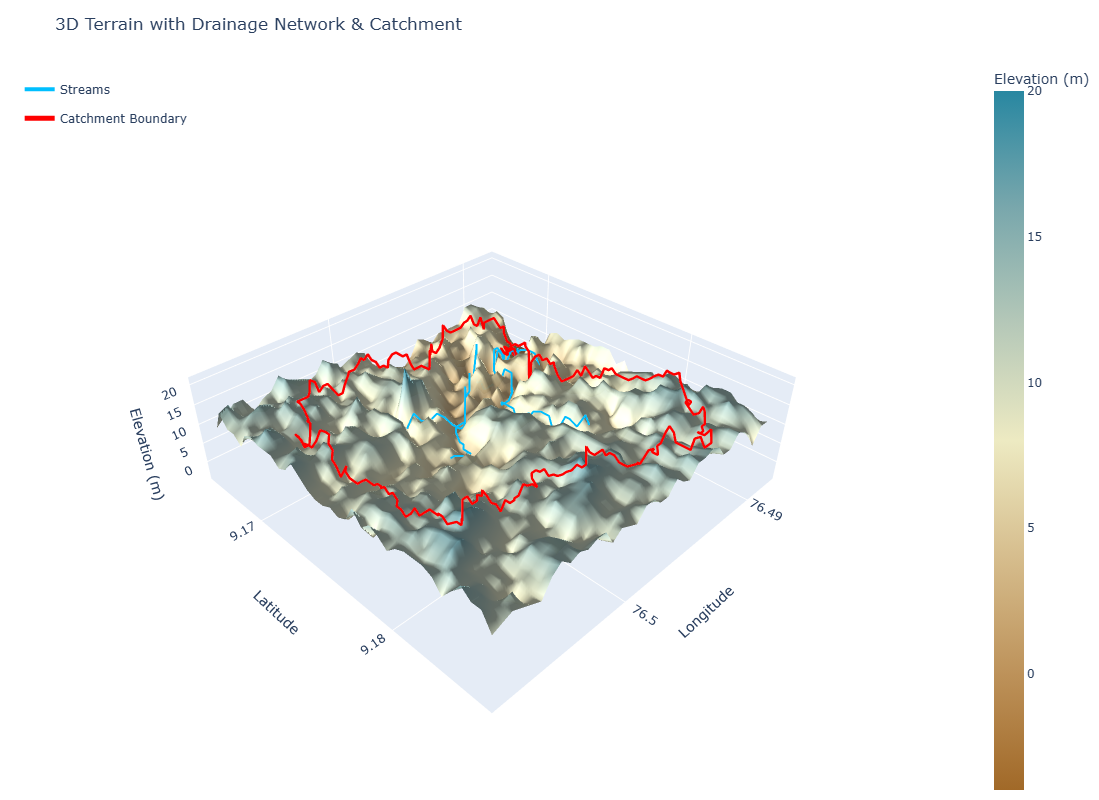

In [41]:


# --- Downsample for performance ---
step = 2
dem_ds = dem.isel(lat=slice(None, None, step), lon=slice(None, None, step))

surface = go.Surface(
    z=dem_ds.values,
    x=dem_ds.lon.values,
    y=dem_ds.lat.values,
    surfacecolor=dem_ds.values,
    colorscale='earth',
    colorbar=dict(title='Elevation (m)', x=1.0),
    opacity=0.95,
    lighting=dict(ambient=0.5, diffuse=0.8, specular=0.3, roughness=0.6),
    lightposition=dict(x=100, y=200, z=1000),
    name='Elevation'
)
fig = go.Figure(data=[surface])
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
# =========================================================
# STREAMS AS POLYLINES — via pysheds' extract_river_network
# =========================================================
branches = grid.extract_river_network(fdir, acc > stream_threshold, dirmap=dirmap)

# Helper: find nearest dem_ds pixel elevation for a given lon/lat (for z-draping)
def nearest_elev(lon, lat):
    lon_idx = np.abs(dem_ds.lon.values - lon).argmin()
    lat_idx = np.abs(dem_ds.lat.values - lat).argmin()
    return dem_ds.values[lat_idx, lon_idx]

first_stream = True
for feature in branches['features']:
    coords = np.array(feature['geometry']['coordinates'])  # [[lon, lat], [lon, lat], ...]
    lons, lats = coords[:, 0], coords[:, 1]
    zs = np.array([nearest_elev(lo, la) for lo, la in zip(lons, lats)]) + 2  # offset above terrain

    fig.add_trace(go.Scatter3d(
        x=lons, y=lats, z=zs,
        mode='lines',
        line=dict(color='deepskyblue', width=4),
        name='Streams',
        legendgroup='streams',
        showlegend=first_stream   # only show one legend entry, not one per branch
    ))
    first_stream = False

# =========================================================
# CATCHMENT BOUNDARY AS A POLYLINE — via contour tracing
# =========================================================
# find_contours needs a binary mask at 0.5 level to trace the outline as ordered vertices
catch_mask = catch.astype(float)
contours = measure.find_contours(catch_mask, level=0.5)

# Take the longest contour (outer boundary) — small contours are usually noise/holes
contour = max(contours, key=len)

# contour gives (row, col) in pixel space — convert to lon/lat using the FULL-res dem grid
# (catch was computed at full resolution, not the downsampled dem_ds, so index into `dem`/`catch`'s own coords)
row_idx = contour[:, 0].astype(int)
col_idx = contour[:, 1].astype(int)

boundary_lon = dem.lon.values[col_idx]
boundary_lat = dem.lat.values[row_idx]
boundary_z   = dem.values[row_idx, col_idx] + 3

fig.add_trace(go.Scatter3d(
    x=boundary_lon, y=boundary_lat, z=boundary_z,
    mode='lines',
    line=dict(color='red', width=5),
    name='Catchment Boundary'
))

fig.update_layout(
    title='3D Terrain with Drainage Network & Catchment',
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Elevation (m)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.3),
    ),
    width=1000,
    height=800,
    margin=dict(l=0, r=0, t=60, b=0),
    legend=dict(x=0.02, y=0.98)
)
fig.show()